<a href="https://colab.research.google.com/github/Linzdhx/Mineria_datos_covid/blob/desarrollo/Mineria_datos_covid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Documentación del Análisis de Inflación Global Post-COVID (2020-2024)

Objetivo principal realizar un análisis exploratorio y preprocesamiento de datos relacionados con la inflación global durante el período post-COVID (2020-2024). El conjunto de datos incluye diversas métricas económicas y financieras para varios países, permitiendo la identificación de patrones, correlaciones y la preparación de los datos para posibles modelos predictivos.

### Nombres: David Yañez y Francisco Fernandez
### Seccion: 002D
### Grupo: 2


Global Inflation Dynamics Post-COVID (2020-2024) [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/ssssws/global-inflation-dynamics-post-covid-20202024.

Repositorio de GIthub: https://github.com/Linzdhx/Mineria_datos_covid/blob/main/Mineria_datos_covid.ipynb

analisis de los datos :b

### 1. Configuración Inicial y Carga de Datos

Esta sección se encarga de importar las librerías necesarias para el análisis y configurar las opciones de visualización de pandas para mostrar todas las columnas y filas de los DataFrames, lo cual es útil para una inspección completa de los datos.

In [ ]:
#importamos librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


In [ ]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas (cuidado si el dataset es muy grande)
pd.set_option('display.max_rows', None)

#### **Resultados de df.head() y de df.tail()**

Se muestran las primeras y ultimas 5 filas del DataFrame. Se puede observar que el dataset contiene columnas como inflacion, petrolio, dinero, comida, etc, Esto nos da una idea de los tipos de datos y la información disponible.

In [ ]:
df = pd.read_csv("/content/covid.csv")
# Ver los primeros registros
print("Primeras 5 filas:")
display(df.head())

Primeras 5 filas:


,country,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index
0,USA,2020-01,0.33,5.76,34.44,0.34,5.97,10558.0,69.95,94.29,3.66
1,USA,2020-02,4.12,4.33,44.75,0.02,5.80,6952.0,71.03,78.60,3.91
2,USA,2020-03,2.75,4.24,52.80,0.30,7.45,10244.0,71.00,102.91,3.70
3,USA,2020-04,4.36,4.52,39.19,2.28,5.23,9989.0,83.52,110.92,3.23
4,USA,2020-05,2.73,3.17,41.09,3.05,5.96,7982.0,70.10,86.53,3.94


In [ ]:
df.tail() #se observan los ultimos datos del data set

,country,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index
99995,AUS,2021-07,4.577258,-0.23,74.99,3.66,7.07,10625.0,96.92,89.26,1.00
99996,TUR,2020-04,1.692581,5.71,36.33,1.45,7.13,9070.0,84.07,116.65,2.78
99997,THA,2024-09,4.363382,2.38,88.02,-1.18,5.59,16805.0,37.97,140.61,1.88
99998,PHL,2020-03,1.285730,4.04,49.48,-0.14,8.12,10400.0,26.36,94.72,3.42
99999,ZAF,2024-02,5.857930,1.90,73.09,2.77,4.08,11590.0,60.02,146.21,2.56


#### **Resultados de `df.shape`**

El DataFrame tiene 100,000 filas y 11 columnas, lo que indica un conjunto de datos considerable para el análisis.

In [ ]:
df.shape #ver cantidad de filas y columnas que contiene el data set

(100000, 11)

#### **Resultados de Verificación de Valores Nulos**

Se comprueba la presencia de valores nulos en cada columna. El resultado muestra que no hay valores nulos en ninguna de las columnas lo cual no es necesario hacer un mapeo de datos.

In [ ]:
# Información general: tipos de datos y si hay valores nulos
for feature in df.columns:
    print('Total de valores nulos de', feature, '=', df[feature].isna().sum())

Total de valores nulos de country = 0
Total de valores nulos de date = 0
Total de valores nulos de inflation_rate = 0
Total de valores nulos de interest_rate = 0
Total de valores nulos de oil_price = 0
Total de valores nulos de gdp_growth = 0
Total de valores nulos de unemployment_rate = 0
Total de valores nulos de money_supply_m2 = 0
Total de valores nulos de exchange_rate_usd = 0
Total de valores nulos de food_price_index = 0
Total de valores nulos de supply_chain_index = 0


**Estadística Descriptiva**

Esta tabla proporciona un resumen estadístico de las columnas numéricas del DataFrame, como la media, la desviación estándar, los valores mínimos y máximos, y los cuartiles. Los valores han sido redondeados para una mejor legibilidad.

In [ ]:
# Estadística descriptiva básica
df.describe().round()

,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index,Riesgo_Cod,country_label
count,100000,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0
mean,2022-06-17 22:14:00.095999744,4.0,3.0,75.0,2.0,6.0,11948.0,47.0,120.0,2.0,1.0,9.0
min,2020-01-01 00:00:00,-2.0,-3.0,23.0,-5.0,2.0,3858.0,2.0,71.0,1.0,0.0,0.0
25%,2021-03-01 00:00:00,3.0,1.0,63.0,1.0,5.0,10060.0,23.0,107.0,1.0,1.0,4.0
50%,2022-07-01 00:00:00,4.0,3.0,75.0,3.0,6.0,11788.0,42.0,120.0,2.0,1.0,9.0
75%,2023-10-01 00:00:00,5.0,4.0,86.0,4.0,6.0,13690.0,73.0,132.0,2.0,1.0,14.0
max,2024-12-01 00:00:00,10.0,8.0,154.0,10.0,9.0,21241.0,105.0,165.0,5.0,2.0,19.0
std,NaN,1.0,2.0,24.0,2.0,1.0,2744.0,30.0,17.0,1.0,0.0,6.0


In [ ]:
df.dtypes # Se muestran los tipos de datos del dataset

,0
country,object
date,object
inflation_rate,float64
interest_rate,float64
oil_price,float64
gdp_growth,float64
unemployment_rate,float64
money_supply_m2,float64
exchange_rate_usd,float64
food_price_index,float64


#### **Resultados de cant_cat_col_pais_df**

Esta sección muestra la cantidad de registros por cada país en el dataset y el número total de países. Se identificaron 20 países distintos con una distribución relativamente uniforme de registros por país.

In [ ]:
cant_cat_col_pais_df = df['country'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de pais
print(cant_cat_col_pais_df)

# Imprimimos la cantidad total de categorias unicas
print(f"cantidad paises: {cant_cat_col_pais_df.count()}")

country
AUS    5103
IDN    5100
TUR    5065
PHL    5047
BRA    5043
EU     5031
CAN    5024
IND    5006
VNM    5000
GBR    4998
ARG    4981
USA    4976
SAU    4976
KOR    4967
CHN    4957
JPN    4955
THA    4951
ZAF    4944
RUS    4942
MEX    4934
Name: count, dtype: int64
cantidad paises: 20


Limpieza y Transformación de Datos

In [ ]:
# Convertir la columna 'date' a formato fecha real para poder extraer años
df['date'] = pd.to_datetime(df['date'])

Después de la conversión de date, se realiza una nueva verificación de valores nulos. El resultado sigue mostrando 0 valores nulos lo que confirma que el dataset esat limpio.

In [ ]:
# Verificar si hay valores nulos por columna
print("Valores nulos encontrados:")
print(df.isnull().sum())

Valores nulos encontrados:
country               0
date                  0
inflation_rate        0
interest_rate         0
oil_price             0
gdp_growth            0
unemployment_rate     0
money_supply_m2       0
exchange_rate_usd     0
food_price_index      0
supply_chain_index    0
dtype: int64


country	Nombre del país.	Categórica	object (string)

date	Fecha del registro.	Temporal	datetime64

inflation_rate	Porcentaje de inflación.	Numérica	float64

interest_rate	Costo del dinero.	Numérica	float64

oil_price	Valor del barril de petróleo en el mercado.	Numérica	float64

gdp_growth	Variación porcentual del crecimiento económico.	Numérica	float64

unemployment_rate	Porcentaje de la población sin empleo.	Numérica	float64

money_supply_m2 dinero circulante en la economía.	Numérica	float64

exchange_rate_usd	Valor de la moneda local frente al dólar.	Numérica	float64

food_price_index	Evolución de los precios de la canasta básica.	Numérica	float64

supply_chain_index	Nivel de interrupción en logística global.	Numérica	float64

Riesgo_Cod	Nivel de riesgo (0: Bajo, 1: Medio, 2: Alto).	Numérica (Ordinal)	int64

country_label	Identificador numérico único para cada país.	Numérica (Nominal)	int64

Análisis Exploratorio

#### **Matriz de Correlación**

El mapa de calor de correlaciones muestra las relaciones lineales entre las variables numéricas. Los valores cercanos a 1 o -1 indican una fuerte correlación positiva o negativa, respectivamente, mientras que los valores cercanos a 0 indican poca o ninguna correlación lineal.

- la variablre de -0.64 significa que cuando el precio del petróleo sube, el índice de la cadena de suministro tiende a bajar significativamente.

-Existe una relación moderada 0.40. que sugiere que a mayor cantidad de dinero en circulación, tienden a subir los precios de las materias primas.

- Variables con correlaciones cercanas a cero sugieren que se mueven de forma independiente entre sí.

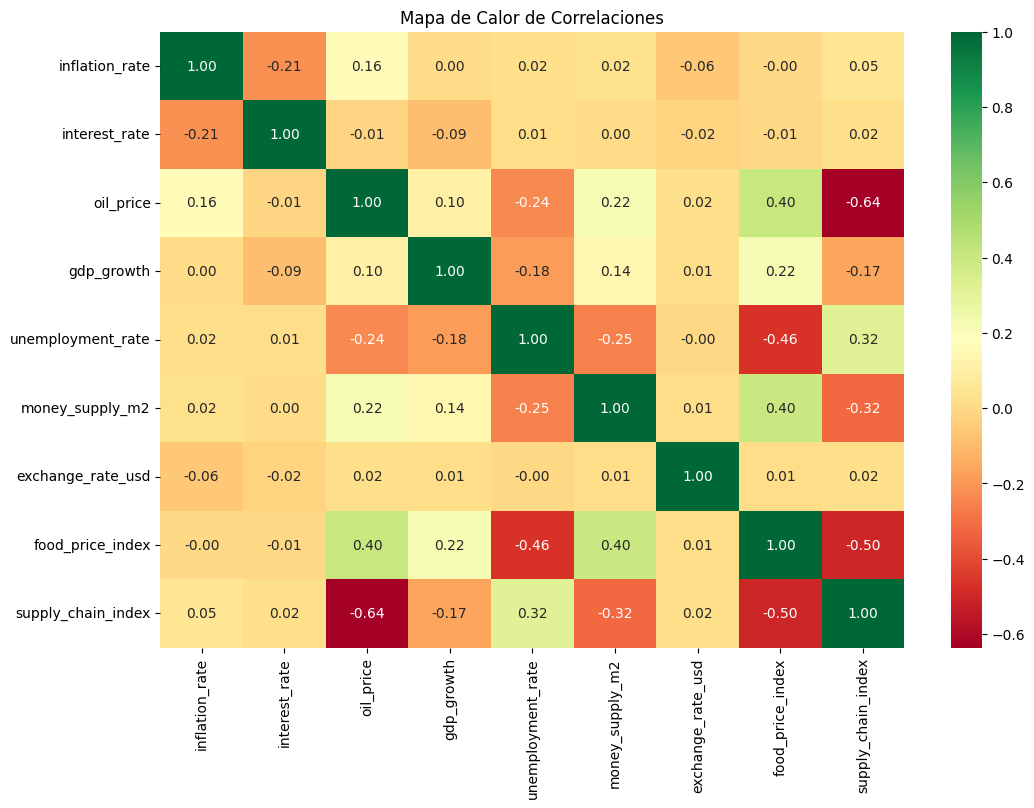

In [ ]:
# 1. Matriz de Correlación: Identificar qué variables se mueven juntas
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Mapa de Calor de Correlaciones")
plt.show()

#### **2. Histograma de la Tasa de Inflación**

La inflación se comporta de manera muy estable y predecible.

Aunque es estable, no parece estar fuertemente ligada a una sola variable, sino que es un fenómeno más complejo.

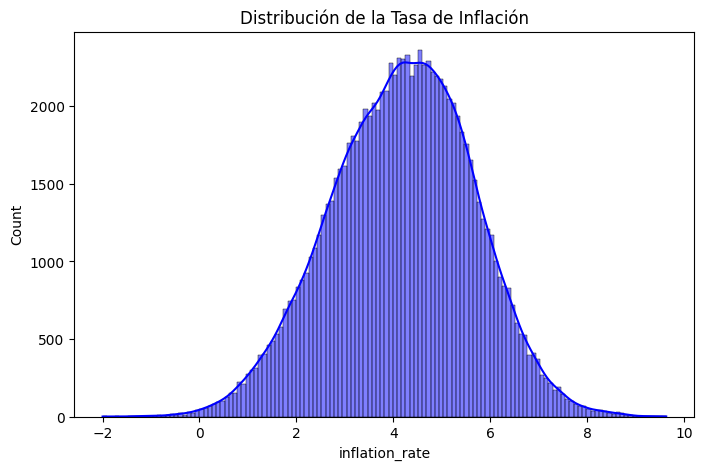

In [ ]:
# 2. Histograma de la variable objetivo (ejemplo: inflation_rate)
plt.figure(figsize=(8, 5))
sns.histplot(df['inflation_rate'], kde=True, color='blue')
plt.title("Distribución de la Tasa de Inflación")
plt.show()

Características (Encoding)

la información de los países para que el modelo pueda procesar cada pais como una característica independiente.



In [ ]:
# Convertir la columna 'country' en columnas numéricas (0 y 1)
df_encoded = pd.get_dummies(df, columns=['country'], drop_first=True)

print("Estructura después del Encoding:")
print(df_encoded.shape)
display(df_encoded.head(3))

Estructura después del Encoding:
(100000, 29)


,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index,country_AUS,country_BRA,country_CAN,country_CHN,country_EU,country_GBR,country_IDN,country_IND,country_JPN,country_KOR,country_MEX,country_PHL,country_RUS,country_SAU,country_THA,country_TUR,country_USA,country_VNM,country_ZAF
0,2020-01-01,0.33,5.76,34.44,0.34,5.97,10558.0,69.95,94.29,3.66,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,2020-02-01,4.12,4.33,44.75,0.02,5.80,6952.0,71.03,78.60,3.91,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,2020-03-01,2.75,4.24,52.80,0.30,7.45,10244.0,71.00,102.91,3.70,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


#### **2. Escalado Min-Max (Normalización)**
Esta técnica es útil cuando se requiere que los datos estén en un rango específico y cuando la distribución de los datos no es continua

In [ ]:
# 1. Definir X (variables predictoras) y Y (lo que quieres predecir)
# Quitamos 'date' porque no es numérica y 'supply_chain_index' que será nuestro objetivo
X = df_encoded.drop(['date', 'supply_chain_index'], axis=1)
y = df_encoded['supply_chain_index']

In [ ]:
# 2. Escalar los datos (Rango 0 a 1)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

### Visualización del Escalado: Distribución de la Tasa de Inflación

Este gráfico compara la distribución de la inflation_rate antes y después de aplicar el MinMaxScaler, mostrando cómo los valores se transforman a un rango de 0 a 1.

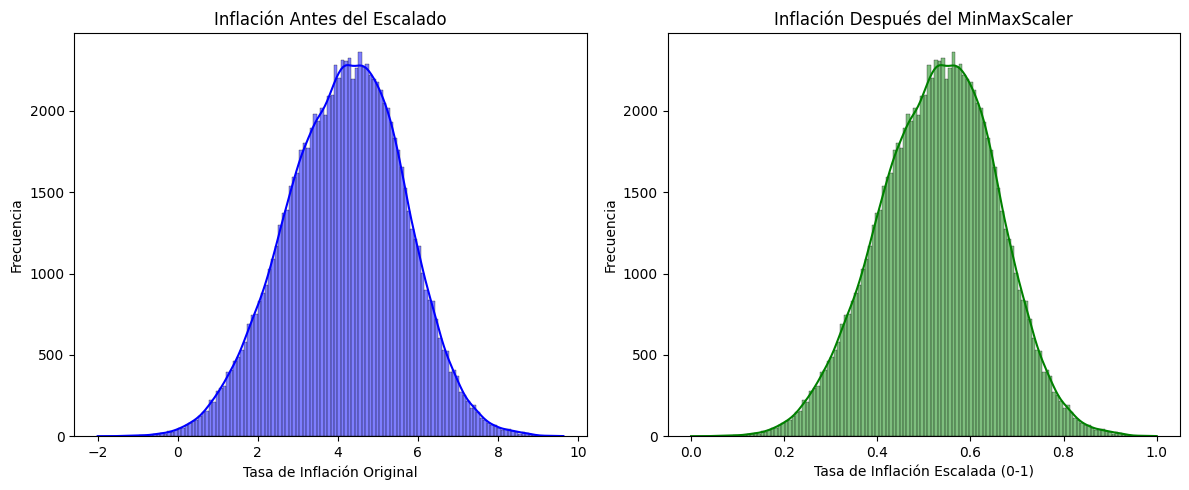

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['inflation_rate'], kde=True, color='blue')
plt.title('Inflación Antes del Escalado')
plt.xlabel('Tasa de Inflación Original')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df_minmax['inflation_rate'], kde=True, color='green')
plt.title('Inflación Después del MinMaxScaler')
plt.xlabel('Tasa de Inflación Escalada (0-1)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

#### **Visualización del Escalado: Distribución de la Tasa de Inflación**

Estos histogramas comparan la distribución de la tasa de inflacion antes y después de aplicar el MinMaxScaler.

- Antes del Escalado:El histograma muestra la distribución original de la tasa de inflación con sus valores reales.

- Después del MinMaxScaler: El histograma muestra la misma distribución de forma asi sabemos que se ha aplicado correctamente, manteniendo la forma de la distribución original pero ajustando su rango.

#### **1. Escalado de Datos (Normalización vs Estandarización)**

Se aplica MinMaxScaler a las columnas oil_price y inflation_rate. asi preparamos los datos para que el modelo trate a la inflación y al petróleo con la misma importancia estadística.

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 1. Normalización Mínimo-Máximo (Rango 0 a 1)
# Muy sensible a outliers (si hay un precio de petróleo de $500, comprime todo lo demás).
scaler_minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[['oil_price', 'inflation_rate']] = scaler_minmax.fit_transform(df[['oil_price', 'inflation_rate']])

#### **2. Estandarización**

Se aplica StandardScaler a las columnas oil_price e inflation_rate. Esta técnica transforma los datos para que tengan una media de 0 y una desviación estándar de 1, haciendo que sigan una distribución similar a la "campana de Gauss".

Al tener ambos códigos estamos comparando para ver cuál da mejor precisión.

In [ ]:
# 2. Estandarización (Media 0, Desviación 1)
# Transforma los datos para que sigan una "Campana de Gauss".
scaler_std = StandardScaler()
df_std = df.copy()
df_std[['oil_price', 'inflation_rate']] = scaler_std.fit_transform(df[['oil_price', 'inflation_rate']])

#### **Resultados de la Comparación de Escalado**
- Se observa que los valores de oil_price e inflation_rate tienen ahora una media cercana a 0 y una desviación estándar cercana a 1.


In [ ]:
print("Datos después de MinMaxScaler (Normalización - Rango 0-1):")
display(df_minmax[['oil_price', 'inflation_rate']].head())

print("\nDatos después de StandardScaler (Estandarización - Media 0, Desviación 1):")
display(df_std[['oil_price', 'inflation_rate']].head())

Datos después de MinMaxScaler (Normalización - Rango 0-1):


,oil_price,inflation_rate
0,0.089987,0.200195
1,0.168611,0.525974
2,0.230001,0.408212
3,0.126211,0.546604
4,0.140700,0.406493



Datos después de StandardScaler (Estandarización - Media 0, Desviación 1):


,oil_price,inflation_rate
0,-1.664728,-2.627835
1,-1.241848,-0.038168
2,-0.911666,-0.974275
3,-1.469900,0.125821
4,-1.391969,-0.987941


Categorías (One-Hot y Ordinal)

In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# --- ONE HOT ENCODING (Variables Nominales: sin orden) ---
encoder_oh = OneHotEncoder(sparse_output=False)
paises_encoded = encoder_oh.fit_transform(df[['country']])
df_paises = pd.DataFrame(paises_encoded, columns=encoder_oh.get_feature_names_out(['country']))

In [ ]:
# --- ORDINAL ENCODING (Variables con jerarquía) ---
# creamos una columna de 'Riesgo_Inflación' (Bajo, Medio, Alto)
categorias = [['Baja', 'Media', 'Alta']]
ord_enc = OrdinalEncoder(categories=categorias)

In [ ]:
# Inventamos una columna para el ejemplo basado en notas
df['Riesgo'] = pd.cut(df['inflation_rate'], bins=3, labels=['Baja', 'Media', 'Alta'])
df['Riesgo_Cod'] = ord_enc.fit_transform(df[['Riesgo']])

#### **Resultados de Ordinal Encoding para 'Riesgo_Inflación'**

Se ha creado una nueva columna Riesgo basada en la tasa de inflación, categorizándola en 'Baja', 'Media' o 'Alta'. Luego, OrdinalEncoder


 asigna un valor numérico a cada categoría ('Baja'->0, 'Media'->1, 'Alta'->2), manteniendo el orden inherente. La columna Riesgo_Cod se añade al DataFrame, reflejando esta codificación ordinal.

# Instalación de la librería necesaria
!pip install category_encoders -q


In [ ]:
!pip install category_encoders -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.2 MB/s eta 0:00:00


### 4. Binary Encoding

La columna country la codificamos binariamente. El DataFrame df_binary muestra las nuevas columnas binarias generadas, Se observa que el número de columnas nuevas es menor que con One-Hot Encoding, lo que demuestra su eficiencia en la reducción de dimensionalidad.

In [ ]:
import category_encoders as ce

# Binary Encoding: Convierte a binario y luego separa en columnas.
# Redusimos drásticamente la dimensionalidad.
encoder_bin = ce.BinaryEncoder(cols=['country'])
df_binary = encoder_bin.fit_transform(df)

display(df_binary.head(3))

,country_0,country_1,country_2,country_3,country_4,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index,Riesgo,Riesgo_Cod
0,0,0,0,0,1,2020-01-01,0.33,5.76,34.44,0.34,5.97,10558.0,69.95,94.29,3.66,Baja,0.0
1,0,0,0,0,1,2020-02-01,4.12,4.33,44.75,0.02,5.80,6952.0,71.03,78.60,3.91,Media,1.0
2,0,0,0,0,1,2020-03-01,2.75,4.24,52.80,0.30,7.45,10244.0,71.00,102.91,3.70,Media,1.0


### 5. Análisis de Correlación de Pearson

Esta sección recalcula y visualiza la matriz de correlación de Pearson pero esta vez con las columnas numéricas que incluyen la Riesgo_Cod y country_label que se generaron Esto permite ver cómo estas nuevas características numéricas se relacionan con las demás variables.

se puede ver que los riesgos se llevan con la inflacion haciendo que si la inflacion suba el riesgo tambien lo haga.

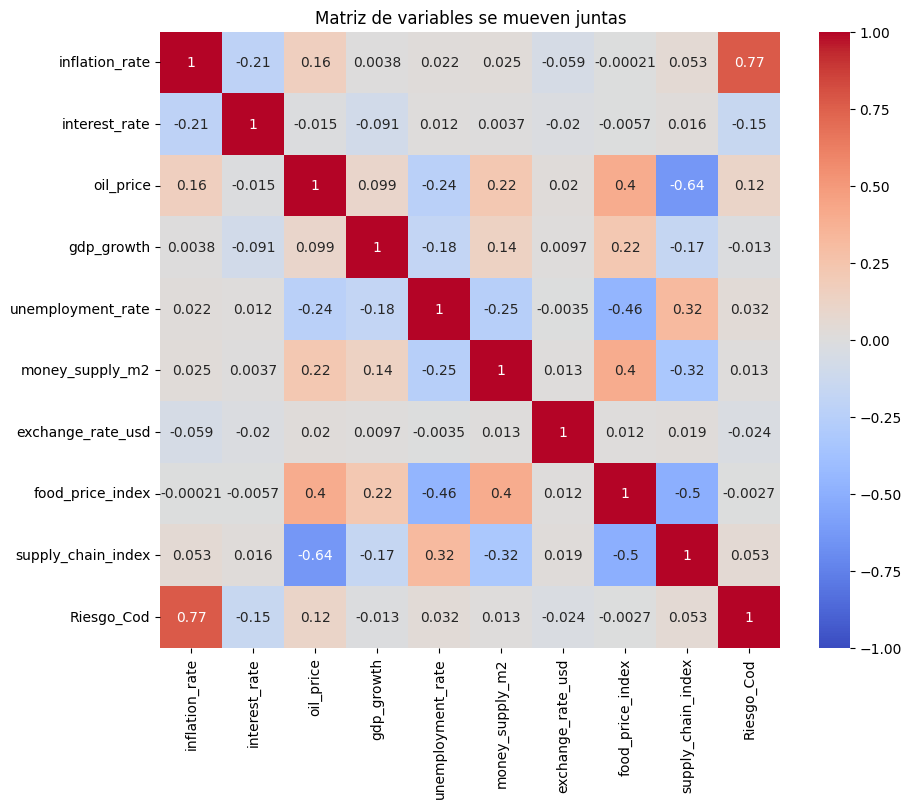

In [ ]:
# Calcular la matriz de correlación de Pearson
# Solo sobre columnas numéricas
matriz_corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)

plt.title("Matriz de variables se mueven juntas")
plt.show()

### 6. Label Encoding

La columna country ha sido transformada en country_label, donde cada país único ha recibido un número entero (0 a 19). Se muestran las clases detectadas por el codificador y un ejemplo de la codificación en las primeras 5 filas.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Si quisiéramos predecir el país (como ejercicio de clasificación)
le = LabelEncoder()
df['country_label'] = le.fit_transform(df['country'])

print(f"Clases detectadas: {le.classes_}")
print(f"Ejemplo de codificación (primeras 5): {df['country_label'].head().values}")

Clases detectadas: ['ARG' 'AUS' 'BRA' 'CAN' 'CHN' 'EU' 'GBR' 'IDN' 'IND' 'JPN' 'KOR' 'MEX'
 'PHL' 'RUS' 'SAU' 'THA' 'TUR' 'USA' 'VNM' 'ZAF']
Ejemplo de codificación (primeras 5): [17 17 17 17 17]
